# Oil Sales Predictive Modeling

This notebook focuses on building and evaluating predictive models for oil sales. We'll cover:
1. Feature engineering
2. Data preprocessing
3. Model development (Random Forest)
4. Model evaluation
5. Feature importance analysis
6. Model interpretation

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# Read the cleaned dataset
df = pd.read_csv('../data/cleaned_data.csv')

In [5]:
# Feature Engineering
def prepare_features(df):
    # Create copy to avoid modifying original dataframe
    df_prep = df.copy()
    
    # Save target variable
    y = df_prep['value_sales']
    
    # Drop store_name, sku, and target variable as they're not features
    df_prep = df_prep.drop(['store_name', 'sku', 'value_sales'], axis=1)
    
    # Add volume_sales as a feature
    numeric_features = ['average_price', 'year', 'month', 'volume_sales']
    
    # Get categorical columns for one-hot encoding
    categorical_features = ['city', 'brand', 'class', 'manufacturer', 'price_bracket']
    
    # One-hot encode categorical variables
    df_encoded = pd.get_dummies(df_prep, columns=categorical_features, drop_first=True)
    
    # Scale numeric features
    scaler = StandardScaler()
    df_encoded[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])
    
    return df_encoded, y, numeric_features

# Prepare features
X, y, numeric_features = prepare_features(df)
print("Features prepared successfully!")
print(f"Number of features: {X.shape[1]}")
print("\nNumeric features:", numeric_features)

Features prepared successfully!
Number of features: 45

Numeric features: ['average_price', 'year', 'month', 'volume_sales']


In [6]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define model and parameters for tuning
model = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Perform grid search with cross-validation
print("Training model with cross-validation...")
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get best model
best_model = grid_search.best_estimator_

# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Calculate metrics
print('\nModel Performance Metrics:')
print('-' * 25)
print('Training Set:')
print(f'R² Score: {r2_score(y_train, y_train_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_train, y_train_pred):.2f}')

print('\nTest Set:')
print(f'R² Score: {r2_score(y_test, y_test_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_test_pred):.2f}')

# Cross-validation score
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')
print(f'\nCross-validation R² scores: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print('\nTop 10 Most Important Features:')
print(feature_importance.head(10))

print(f'\nBest Parameters: {grid_search.best_params_}')

Training model with cross-validation...

Model Performance Metrics:
-------------------------
Training Set:
R² Score: 0.9963
RMSE: 46.11
MAE: 12.18

Test Set:
R² Score: 0.9928
RMSE: 61.54
MAE: 20.04

Cross-validation R² scores: 0.9848 (+/- 0.0101)

Top 10 Most Important Features:
                            feature  importance
3                      volume_sales    0.734502
4                     average_price    0.258016
0                              size    0.001850
2                             month    0.001059
33          manufacturer_NOVA FOODS    0.000702
42              price_bracket_71-80    0.000390
1                              year    0.000354
18                       brand_LARA    0.000248
23                     brand_SABAYA    0.000226
34  manufacturer_PALM & GRAIN GROUP    0.000188

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


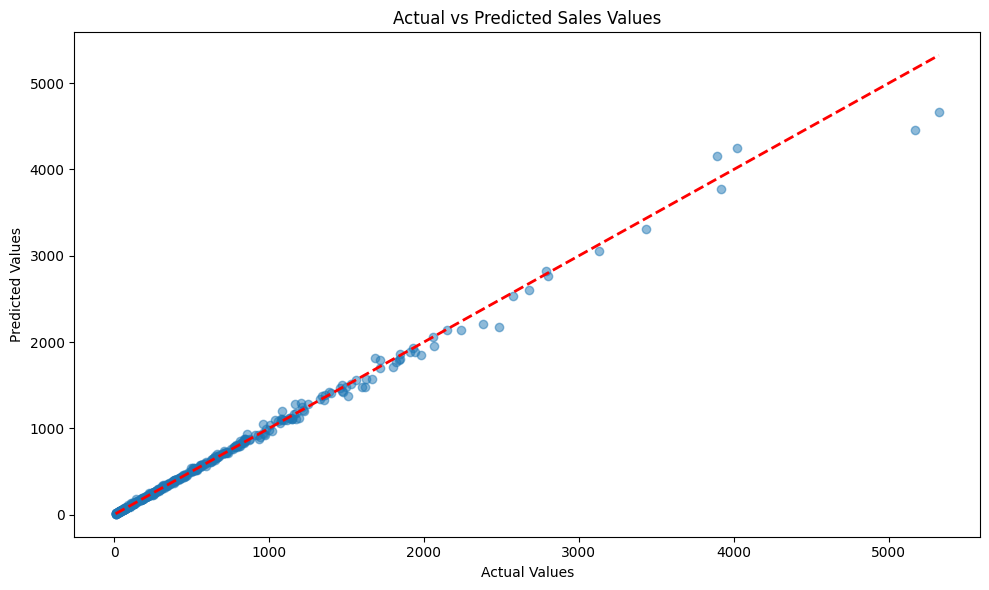

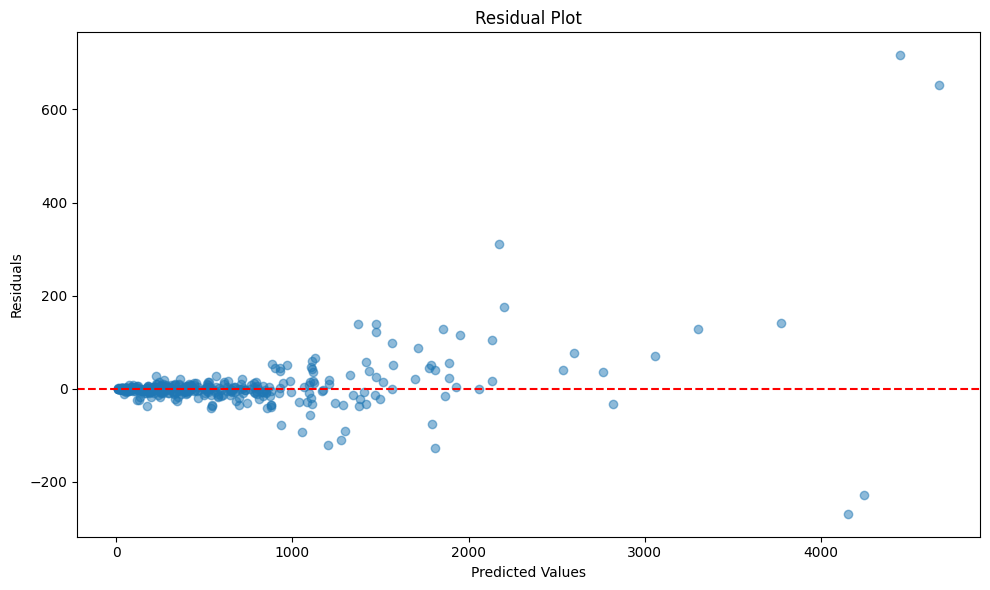

In [7]:
# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Sales Values')
plt.tight_layout()
plt.show()

# Plot residuals
residuals = y_test - y_test_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [9]:
# Save the model and feature names
import joblib

# Save the model
joblib.dump(best_model, '../models/oil_sales_model.pkl')

# Save the feature names
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../models/feature_names.pkl')

print("Model and feature names saved successfully!")

Model and feature names saved successfully!


In [8]:
# Save the model and scaler
import joblib

# Save the model
joblib.dump(best_model, '../models/oil_sales_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [10]:
# Save the model and feature information
import joblib

# Save the feature columns
feature_info = {
    'feature_names': X.columns.tolist(),
    'numeric_features': numeric_features
}

# Save both model and feature info
joblib.dump(best_model, '../models/oil_sales_model.pkl')
joblib.dump(feature_info, '../models/feature_info.pkl')
print("Model and feature information saved successfully!")

Model and feature information saved successfully!
